# Data Cleaning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

churn_df = pd.read_csv(r'D:\Clubs and Misc. Activities\Analytics Club\Stratify\customer_churn_data.csv')
demo_df  = pd.read_csv(r'D:\Clubs and Misc. Activities\Analytics Club\Stratify\demographic_data.csv')
sub_df = pd.read_csv(r'D:\Clubs and Misc. Activities\Analytics Club\Stratify\subscription_payment_history.csv')

# Merge churn data with demographic info
merged_df = pd.merge(churn_df, demo_df, on="CustomerID", how="left")

# Merge the result with subscription history
merged_df = pd.merge(merged_df, sub_df, on=["CustomerID", "SubscriptionPlan"], how="left")

# Check the result



merged_df.describe()
merged_df['Login']=merged_df['Login'].astype(int)
merged_df['Churned']=merged_df['Churned'].astype(int)
merged_df['IsAutoRenew']=merged_df['IsAutoRenew'].astype(int)
merged_df['Date'] = pd.to_datetime(merged_df['Date'], format="%d-%m-%Y")
merged_df['ChurnDate'] = pd.to_datetime(merged_df['ChurnDate'], format="%d-%m-%Y")
cat_cols = ['SubscriptionPlan', 'AgeGroup', 'ContentPreference',
            'Location', 'PrimaryDevice', 'BillingCycle']
merged_df[cat_cols] = merged_df[cat_cols].astype('category')
merged_df['CustomerID']=merged_df['CustomerID'].astype('string')

merged_df.to_csv("merged_customer_data.csv", index=False)

# Quick look
print(merged_df.info())
print(merged_df.describe(include='all'))       # Overview for numerical and categorical
print(merged_df.head())
print(merged_df.isnull().sum())                # Missing values per column


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20967 entries, 0 to 20966
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         20967 non-null  string        
 1   Date               20967 non-null  datetime64[ns]
 2   SubscriptionPlan   20967 non-null  category      
 3   AgeGroup           20967 non-null  category      
 4   Login              20967 non-null  int32         
 5   WatchTimeMinutes   20967 non-null  int64         
 6   ContentPreference  20967 non-null  category      
 7   Churned            20967 non-null  int32         
 8   ChurnDate          45 non-null     datetime64[ns]
 9   Location           20967 non-null  category      
 10  HouseholdSize      20967 non-null  int64         
 11  PrimaryDevice      20967 non-null  category      
 12  BillingCycle       20967 non-null  category      
 13  IsAutoRenew        20967 non-null  int32         
dtypes: cat

# EDA Analysis

In [ ]:
for col in merged_df.columns:
    print(col)
    print(merged_df[col].unique())
    print("")


churned_customers = merged_df.groupby("CustomerID")["Churned"].transform("max")

unique_cust_data = pd.concat([
    merged_df[(churned_customers == 1) & (merged_df["Churned"] == 1)],
    merged_df[(churned_customers == 0)].drop_duplicates(subset="CustomerID", keep="first")
])
unique_cust_data = unique_cust_data.sort_values('CustomerID')
unique_cust_data = unique_cust_data.drop(columns=['Date', 'ChurnDate'])
print(unique_cust_data)


CustomerID
<StringArray>
['CUST001', 'CUST002', 'CUST003', 'CUST004', 'CUST005', 'CUST006', 'CUST007',
 'CUST008', 'CUST009', 'CUST010',
 ...
 'CUST241', 'CUST242', 'CUST243', 'CUST244', 'CUST245', 'CUST246', 'CUST247',
 'CUST248', 'CUST249', 'CUST250']
Length: 250, dtype: string

Date
<DatetimeArray>
['2025-04-01 00:00:00', '2025-04-02 00:00:00', '2025-04-03 00:00:00',
 '2025-04-04 00:00:00', '2025-04-05 00:00:00', '2025-04-06 00:00:00',
 '2025-04-07 00:00:00', '2025-04-08 00:00:00', '2025-04-09 00:00:00',
 '2025-04-10 00:00:00', '2025-04-11 00:00:00', '2025-04-12 00:00:00',
 '2025-04-13 00:00:00', '2025-04-14 00:00:00', '2025-04-15 00:00:00',
 '2025-04-16 00:00:00', '2025-04-17 00:00:00', '2025-04-18 00:00:00',
 '2025-04-19 00:00:00', '2025-04-20 00:00:00', '2025-04-21 00:00:00',
 '2025-04-22 00:00:00', '2025-04-23 00:00:00', '2025-04-24 00:00:00',
 '2025-04-25 00:00:00', '2025-04-26 00:00:00', '2025-04-27 00:00:00',
 '2025-04-28 00:00:00', '2025-04-29 00:00:00', '2025-04-30 00:00:00

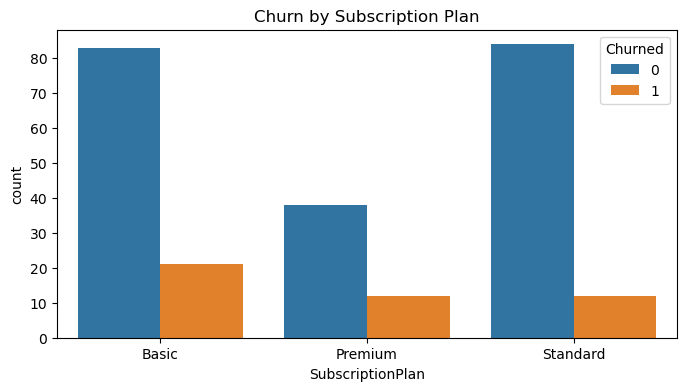

C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby('SubscriptionPlan').size()


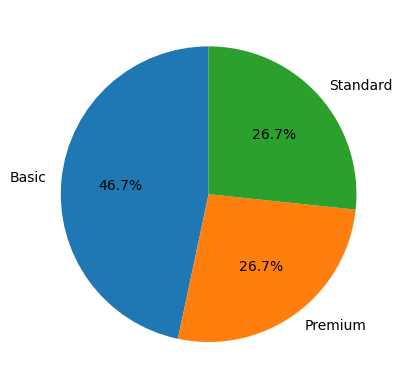

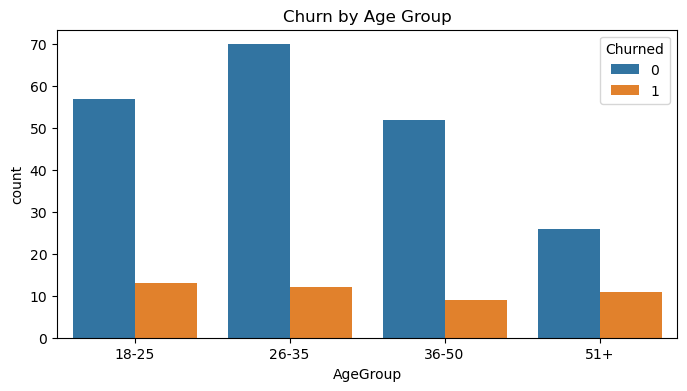

C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby('AgeGroup').size()


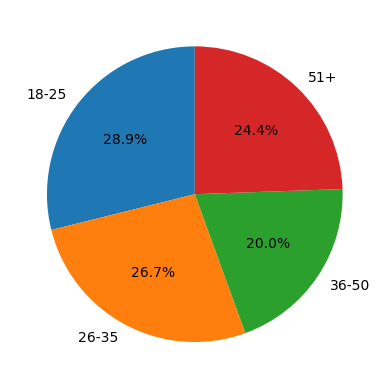

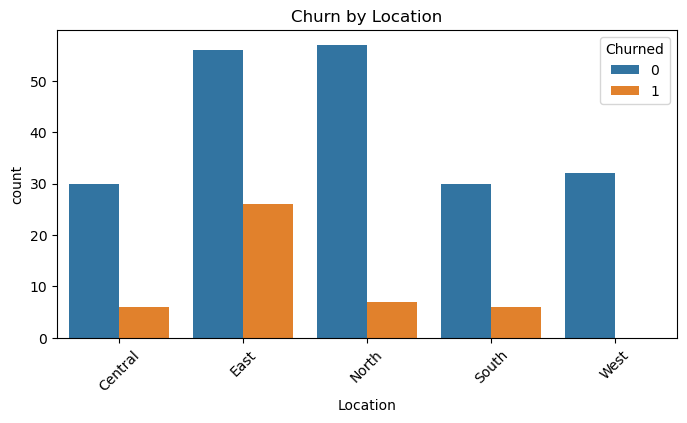

C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby(col).size()


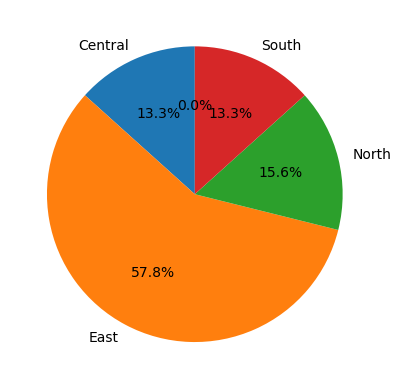

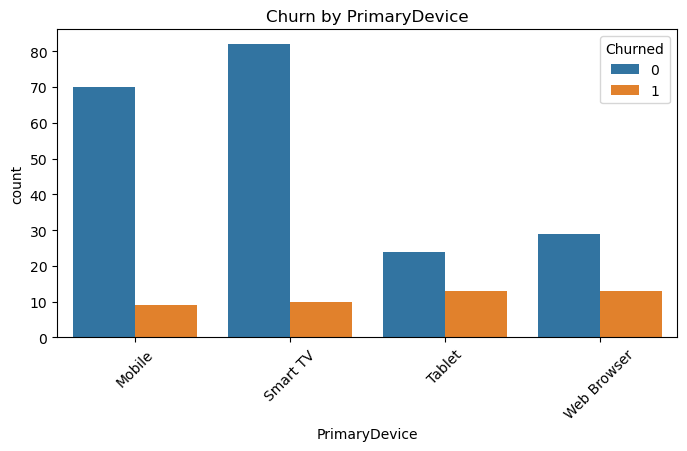

C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby(col).size()


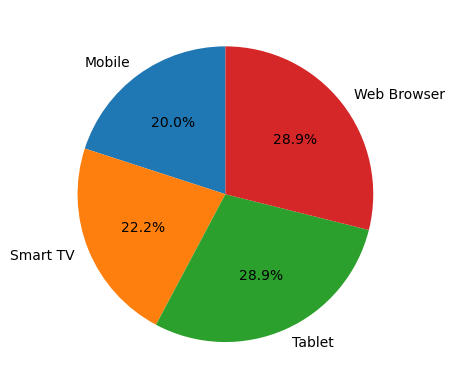

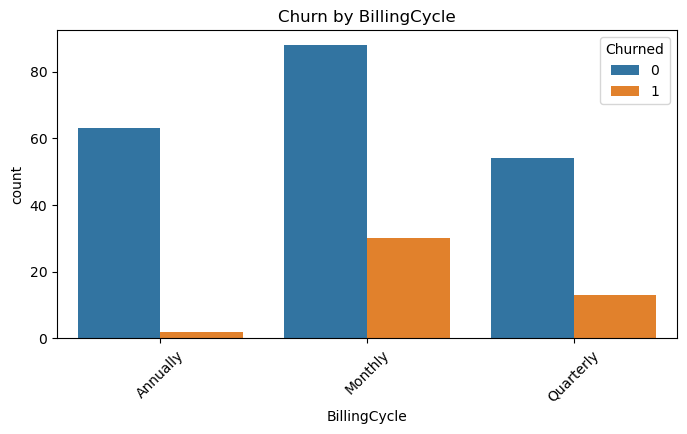

C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby(col).size()


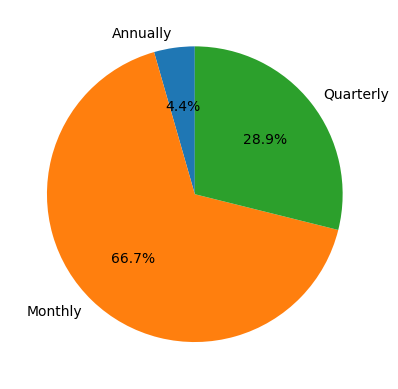

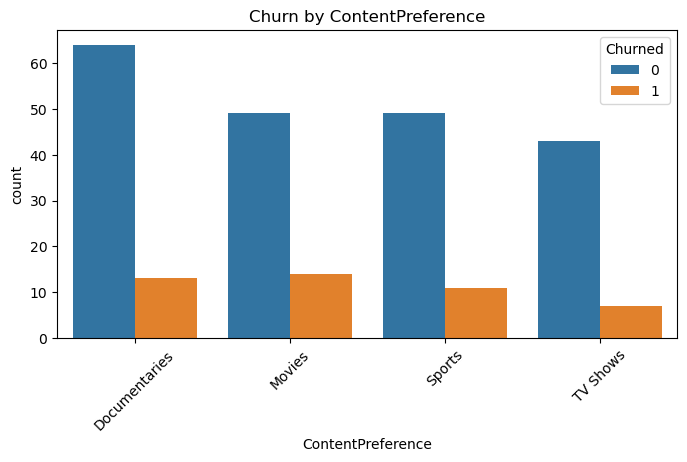

C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby(col).size()


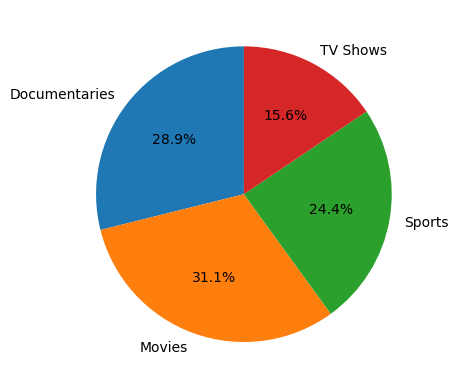

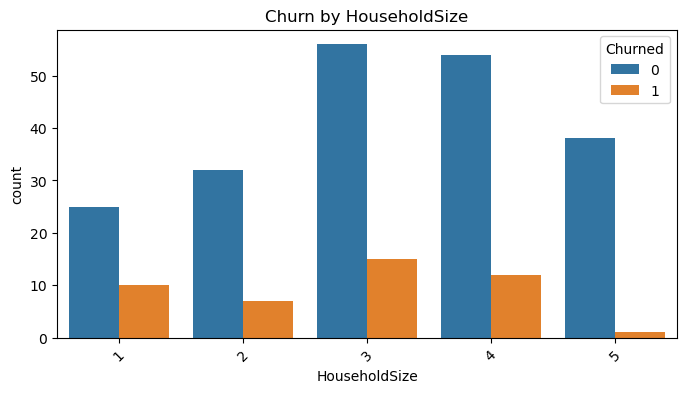

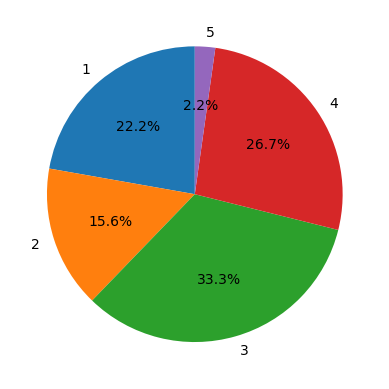

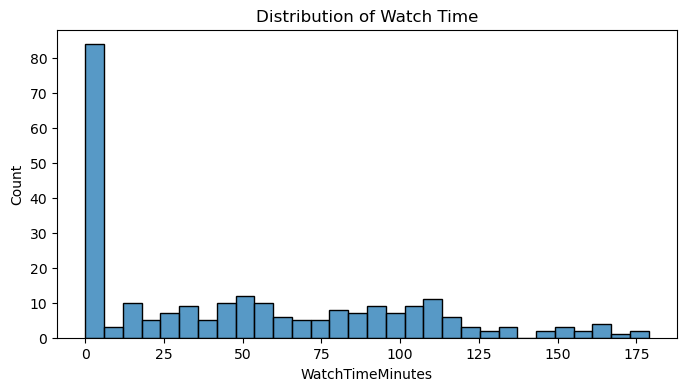

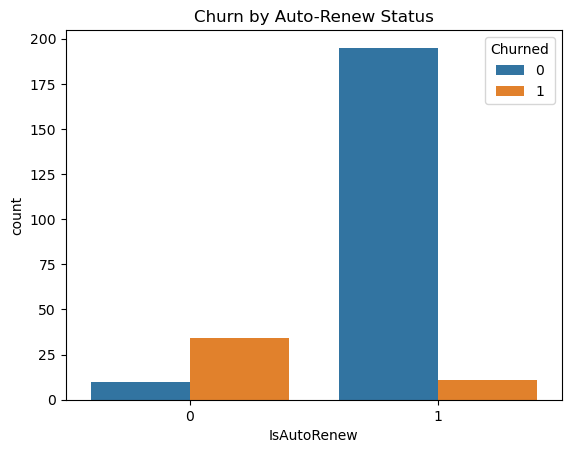

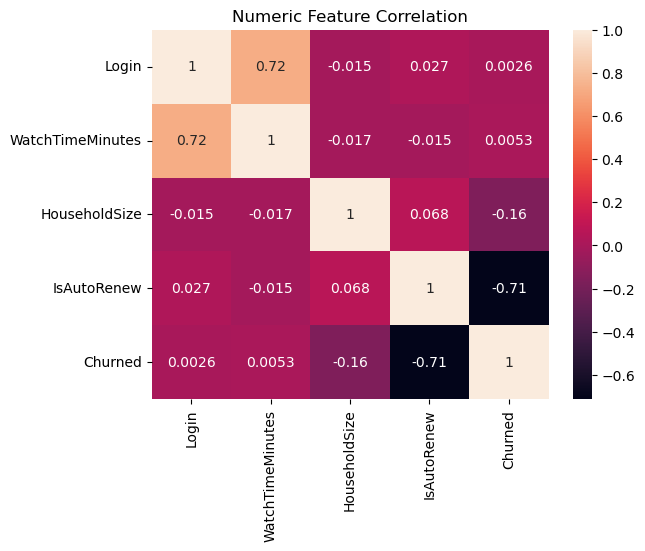

SubscriptionPlan  Churned
Basic             0           17.409639
                  1           19.238095
Premium           0          113.552632
                  1           82.250000
Standard          0           53.750000
                  1           74.583333
Name: WatchTimeMinutes, dtype: float64
Churned                     0  1
SubscriptionPlan AgeGroup       
Basic            18-25     19  4
                 26-35     31  6
                 36-50     21  5
                 51+       12  6
Premium          18-25     15  5
                 26-35     10  3
                 36-50     11  4
                 51+        2  0
Standard         18-25     23  4
                 26-35     29  3
                 36-50     20  0
                 51+       12  5
SubscriptionPlan  Churned
Basic             0           17.409639
                  1           19.238095
Premium           0          113.552632
                  1           82.250000
Standard          0           53.750000
       

C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(unique_cust_data.groupby(['SubscriptionPlan', 'Churned'])['WatchTimeMinutes'].mean())
C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(
C:\Users\manan\AppData\Local\Temp\ipykernel_36556\3889296009.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warni

In [ ]:
# Churn rate by SubscriptionPlan
plt.figure(figsize=(8,4))
sns.countplot(x='SubscriptionPlan', hue='Churned', data=unique_cust_data)
plt.title("Churn by Subscription Plan")
plt.show()

# Plot pie chart
counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby('SubscriptionPlan').size()
counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.ylabel('')  # Hide the y-axis label
plt.show()

# Churn rate by AgeGroup
plt.figure(figsize=(8,4))
sns.countplot(x='AgeGroup', hue='Churned', data=unique_cust_data)
plt.title("Churn by Age Group")
plt.show()

# Plot pie chart
counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby('AgeGroup').size()
counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.ylabel('')  # Hide the y-axis label
plt.show()

# Churn Rate by Location, Device, BillingCycle, ContentPreference
for col in ['Location', 'PrimaryDevice', 'BillingCycle', 'ContentPreference', 'HouseholdSize']:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Churned', data=unique_cust_data)
    plt.title(f'Churn by {col}')
    plt.xticks(rotation=45)
    plt.show()

    # Plot pie chart
    counts = unique_cust_data[unique_cust_data['Churned'] == 1].groupby(col).size()
    counts.plot.pie(autopct='%1.1f%%', startangle=90)
    plt.ylabel('')  # Hide the y-axis label
    plt.show()

# Distribution of WatchTimeMinutes
plt.figure(figsize=(8,4))
sns.histplot(unique_cust_data['WatchTimeMinutes'], bins=30)
plt.title("Distribution of Watch Time")
plt.show()

# Autorenew Status
sns.countplot(x='IsAutoRenew', hue='Churned', data=unique_cust_data)
plt.title("Churn by Auto-Renew Status")
plt.show()

# Correlation Analysis
corr = unique_cust_data[['Login', 'WatchTimeMinutes', 'HouseholdSize', 'IsAutoRenew', 'Churned']].corr()
sns.heatmap(corr, annot=True)
plt.title('Numeric Feature Correlation')
plt.show()

# Average watch time by subscription and churn status
print(unique_cust_data.groupby(['SubscriptionPlan', 'Churned'])['WatchTimeMinutes'].mean())




pivot = pd.pivot_table(
    unique_cust_data,
    values='CustomerID',
    index=['SubscriptionPlan', 'AgeGroup'],
    columns='Churned',
    aggfunc='count',
    fill_value=0
)
print(pivot)

# Average watch time by subscription and churn status
print(unique_cust_data.groupby(['SubscriptionPlan', 'Churned'])['WatchTimeMinutes'].mean())

# Churn rate by primary device
print(unique_cust_data.groupby('PrimaryDevice')['Churned'].mean())

# Predictive Churn Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def train_test_split_and_features(df_features):
    # Target variable
    y = df_features["Churned"]

    # Features (dropping target)
    x = df_features.drop('Churned', axis=1)

    # One-hot encode categorical variables
    x = pd.get_dummies(x, dtype=int)

    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.20, random_state=0
    )

    # Print sample data and column names for verification
    print(x.head(5))
    print(x.columns)

    # Save list of feature names
    features = list(x.columns)

    return x_train, x_test, y_train, y_test, features


In [ ]:
categorical_features = ['SubscriptionPlan', 'AgeGroup', 'ContentPreference', 'Location', 'HouseholdSize', 'PrimaryDevice', 'BillingCycle']
numerical_features = ['Login', 'IsAutoRenew']
df_features = unique_cust_data[numerical_features + categorical_features + ['Churned']]

x_train, x_test, y_train, y_test, features = train_test_split_and_features(df_features)

     Login  IsAutoRenew  HouseholdSize  SubscriptionPlan_Basic  \
51       1            0              3                       1   
52       0            1              1                       1   
143      1            1              4                       1   
234      1            1              5                       0   
325      0            1              5                       0   

     SubscriptionPlan_Premium  SubscriptionPlan_Standard  AgeGroup_18-25  \
51                          0                          0               0   
52                          0                          0               0   
143                         0                          0               0   
234                         0                          1               0   
325                         1                          0               1   

     AgeGroup_26-35  AgeGroup_36-50  AgeGroup_51+  ...  Location_North  \
51                0               1             0  ...               0  

In [ ]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE

def fit_and_evaluate_model(x_train, x_test, y_train, y_test,
                           max_depth=5, min_samples_split=0.01,
                           max_features=0.8, max_samples=0.8):

    # --- Step 1: Apply SMOTE to balance the training set ---
    sm = SMOTE(random_state=42)
    X_resampled, y_resampled = sm.fit_resample(x_train, y_train)

    print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
    print(f"After SMOTE:  {pd.Series(y_resampled).value_counts().to_dict()}\n")

    # --- Step 2: Initialize Random Forest with class weights (optional but useful) ---
    random_forest = RandomForestClassifier(
        random_state=0,
        class_weight="balanced",   # still keeps weighting, in case imbalance remains
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        max_samples=max_samples
    )

    # --- Step 3: Train model on balanced data ---
    model = random_forest.fit(X_resampled, y_resampled)

    # --- Step 4: Predictions on untouched test set ---
    y_pred = random_forest.predict(x_test)

    # --- Step 5: Evaluation ---
    conf_matrix = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)

    # ROC-AUC
    try:
        roc_auc = roc_auc_score(y_test, random_forest.predict_proba(x_test)[:,1])
    except ValueError:
        roc_auc = "N/A (only one class in test set)"

    # --- Step 6: Print results ---
    print("Confusion Matrix:")
    print(conf_matrix, "\n")

    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision (Churn=1): {precision:.4f}")
    print(f"Recall (Churn=1):    {recall:.4f}")
    print(f"F1-Score (Churn=1):  {f1:.4f}")
    print(f"ROC-AUC:             {roc_auc}\n")

    print("Detailed Report:\n", classification_report(y_test, y_pred, digits=4))

    return model





In [ ]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)

Before SMOTE: {0: 162, 1: 38}
After SMOTE:  {0: 162, 1: 162}

Confusion Matrix:
[[40  3]
 [ 1  6]] 

Accuracy: 92.00%
Precision (Churn=1): 0.6667
Recall (Churn=1):    0.8571
F1-Score (Churn=1):  0.7500
ROC-AUC:             0.9136212624584718

Detailed Report:
               precision    recall  f1-score   support

           0     0.9756    0.9302    0.9524        43
           1     0.6667    0.8571    0.7500         7

    accuracy                         0.9200        50
   macro avg     0.8211    0.8937    0.8512        50
weighted avg     0.9324    0.9200    0.9240        50

